# FFT Cross-Correlation Sandbox

Compute FFT-based shift vectors between adjacent masked frames from the tracker output. The notebook loads the same config so it can locate the processed cropped images, builds a dilated mask to remove the tracked object, and reports the peak cross-correlation shift for a few pairs.


In [8]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml

CONFIG_PATH = Path('../configs/opencv_tracker_v3.yaml')
config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
input_cfg = config["input"]
base_dir = Path(input_cfg["base_dir"]).resolve()
raw_root = Path(input_cfg.get("raw_root", "/Volumes/Extreme SSD/deep-sea-particles-gm/raw")).resolve()
try:
    relative = base_dir.relative_to(raw_root)
except ValueError:
    relative = Path(base_dir.name)
processed_root = Path(config["output"].get("processed_root", "/Volumes/Extreme SSD/deep-sea-particles-gm/processed")).resolve()
crops_subdir = config["output"].get("crops_subdir", "cropped") or "cropped"
processed_expt_dir = processed_root / relative
crops_dir = processed_expt_dir / crops_subdir
print("crops dir", crops_dir)


crops dir /Volumes/Extreme SSD/deep-sea-particles-gm/processed/pyrite_2024-11-14 20-00-15.825503_good/cropped


In [9]:
def natural_sort_key(path):
    parts = []
    for token in path.stem.split("_"):
        if token.isdigit():
            parts.append(int(token))
        else:
            parts.append(token.lower())
    return parts

def collect_sequence(folder, extensions=(".png", ".tif", ".bmp")):
    candidates = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in extensions and not p.name.startswith(".")]
    return sorted(candidates, key=natural_sort_key)


In [10]:
folders = [entry for entry in crops_dir.iterdir() if entry.is_dir()]
if not folders:
    raise RuntimeError("no cropped folders")
sequence = collect_sequence(folders[0])
print("using", folders[0], "with", len(sequence), "frames")


using /Volumes/Extreme SSD/deep-sea-particles-gm/processed/pyrite_2024-11-14 20-00-15.825503_good/cropped/0_cropped with 306 frames


(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

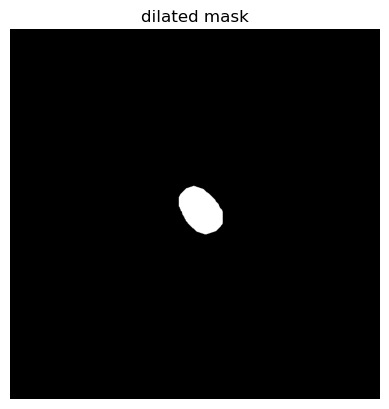

In [11]:
def histogram_stretch(image, lower_pct=0.5, upper_pct=99.5):
    arr = np.asarray(image, dtype=np.float32)
    lo = np.percentile(arr, lower_pct)
    hi = np.percentile(arr, upper_pct)
    if hi <= lo:
        return np.clip(arr, 0, 255).astype(np.uint8)
    stretched = (arr - lo) * (255.0 / (hi - lo))
    return np.clip(stretched, 0, 255).astype(np.uint8)

def build_mask(frame):
    _, mask = cv2.threshold(frame, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Keep only the largest contour
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [largest_contour], -1, color=255, thickness=cv2.FILLED)
        
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.dilate(mask, kernel, iterations=5)
    return mask

first = cv2.imread(str(sequence[0]), cv2.IMREAD_GRAYSCALE)
mask = build_mask(first)
plt.imshow(mask, cmap="gray")
plt.title("dilated mask")
plt.axis("off")


In [ ]:
def fft_cross_correlation_shift(frame_a, frame_b, mask=None):
    fa = frame_a.astype(np.float32)
    fb = frame_b.astype(np.float32)
    if mask is not None:
        ma = (mask > 0).astype(np.float32)
        fa *= (1 - ma)
        fb *= (1 - ma)
    fa = (fa - fa.mean()) / (fa.std() + 1e-8)
    fb = (fb - fb.mean()) / (fb.std() + 1e-8)
    F = np.fft.fft2(fa)
    G = np.fft.fft2(fb)
    cross = F * np.conj(G)
    cross = np.fft.ifftshift(np.fft.ifft2(cross))
    shift_idx = np.unravel_index(np.argmax(np.abs(cross)), cross.shape)
    center = np.array(cross.shape) // 2
    shift = np.array(shift_idx) - center
    return int(shift[0]), int(shift[1]), cross

In [14]:
pairs = []
for i in range(min(5, len(sequence) - 1)):
    frame_a = cv2.imread(str(sequence[i]), cv2.IMREAD_GRAYSCALE)
    frame_b = cv2.imread(str(sequence[i + 1]), cv2.IMREAD_GRAYSCALE)
    shift = fft_cross_correlation_shift(frame_a, frame_b, mask)
    pairs.append(shift)
print("cross-correlation shifts", pairs)


cross-correlation shifts [(0, 0), (0, 0), (0, 0), (0, 0), (0, 0)]


# Tests



known shift (10, 4) estimated shift (-10, -4)


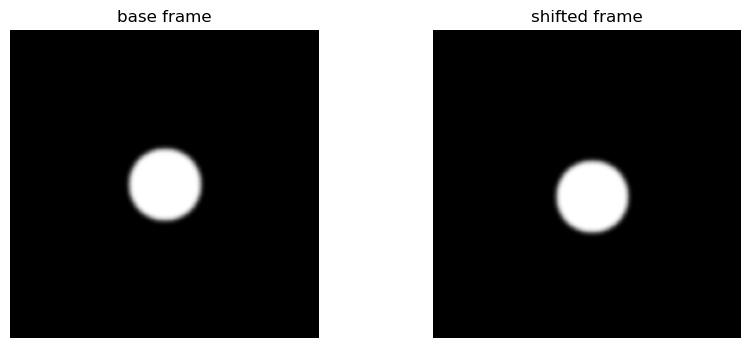

In [6]:
def synthetic_pair(shape=(256, 256), shift=(5, -3)):
    canvas = np.zeros(shape, dtype=np.float32)
    cv2.circle(canvas, (shape[1]//2, shape[0]//2), 30, 255, -1)
    grid = np.indices(shape).transpose(1, 2, 0)
    frame = cv2.GaussianBlur(canvas, (11, 11), 0)
    shifted = np.roll(np.roll(frame, shift[0], axis=0), shift[1], axis=1)
    return frame.astype(np.uint8), shifted.astype(np.uint8)

known_shift = (10, 4)
base, shifted = synthetic_pair(shift=known_shift)
estimated = fft_cross_correlation_shift(base, shifted, mask=None)
print('known shift', known_shift, 'estimated shift', estimated)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].set_title('base frame')
axes[0].imshow(base, cmap='gray')
axes[1].set_title('shifted frame')
axes[1].imshow(shifted, cmap='gray')
for ax in axes:
    ax.axis('off')

## Notes
- Compare the FFT shifts with the tracked OpenPIV vectors stored in the processed data,
  or use these estimates to initialize a tracking guess.
